## Fixing Individual Objects - Alexandros Pratsos, last edited 05/10/2025

### This notebook is meant to edit individual objects by manually filtering bad pixels and/or changing the ICA weights used for the fitting

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('.'))+"\\components")
sys.path.append(os.path.abspath(os.path.join('.'))+"\\ICA Scripts")

import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib
# import richardsplot as rplot

from astropy.io import fits
from astropy.table import Table
import pandas as pd

#sys.path.append("/Volumes/Macintosh HD 1/Users/trevormccaffrey/Desktop/HST/AllHSTCode/")
# sys.path.append("/Users/trevormccaffrey/Dropbox/HST/HSTCode/")
#sys.path.append("/Users/trevormccaffrey/Dropbox/HST/HSTCode/")
from Small_Pix_Filter_TVM import SDSS_pixel_filter
import MorphingEdges_FOS
import MorphingEdges_STIS
import MorphingEdges_COS
import MorphingEdges_HSLA
import MorphingEdges
import CIV_BAL_regions
#Use the package that Amy used for determining weights
from lmfit import minimize, Parameters

# sys.path.append("/Users/trevormccaffrey/Dropbox/ICA_module/code_main/")
#sys.path.append("/Users/Trevor1/Dropbox/ICA_module/")
import run_ICA_r20_components
import components
import spec_morph
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

In [3]:
%%capture
def blueshift(wave_half_flux):
    return ((1549.48 - wave_half_flux) / 1549.48) * 3e5

def get_CIV(wave, flux, wave_r, flux_r, name, ax=plt.gca(), EW_region=[1500,1600], cont_region=[[1445,1465],[1700,1705]], good=1):
    #print("Getting CIV")
    #Going to save plots, but not show with magic above
    #"""
    ylow, yup = max(0, np.percentile(flux_r, 1)-np.nanmedian(flux_r)/5), np.percentile(flux_r, 99)+np.nanpercentile(flux_r, 99)
    #fig, ax = plt.subplots(figsize=(9,9))
    #fig = plt.figure(figsize=(9,9))
    ax.plot(wave, flux, "-k", alpha=0.5)#, label="HST co-add")
    ax.plot(wave_r, flux_r, "-r", lw=1.8)#, label="ICA fit")
    ax.plot([1549.48,1549.48], [ylow,yup], "--k", label="CIV Rest")
    #"""
    
    #Fit continuum -- ADD MANUAL HERE
    cont1 = ((wave_r>=cont_region[0][0])&(wave_r<=cont_region[0][1]))
    cont2 = ((wave_r>=cont_region[1][0])&(wave_r<=cont_region[1][1]))
    ax.axvspan(cont_region[0][0], cont_region[0][1], alpha=0.5, color='grey')
    ax.axvspan(cont_region[1][0], cont_region[1][1], alpha=0.5, color='grey')

    m,b = np.polyfit(np.concatenate((wave_r[cont1], wave_r[cont2])), np.concatenate((flux_r[cont1], flux_r[cont2])), 1)
    continuum = wave_r*m + b
    ax.plot(wave_r, continuum, "-m")
    
    #Plot EW region under flux_r -- ADD MANUAL HERE
    EW = ((wave_r>=EW_region[0])&(wave_r<=EW_region[1]))

    #And compute the EW
    CIV_EW = 0
    ew_list = [0.]
    for i in range(len(wave_r[EW])):
        try:
            CIV_EW += max(( (flux_r[EW][i] - continuum[i]) / continuum[i] ) * ( wave_r[EW][i+1] - wave_r[EW][i] ), 0) #no absorption
        except IndexError:
            CIV_EW += max(( (flux_r[EW][i] - continuum[i]) / continuum[i] ) * ( wave_r[EW][i] - wave_r[EW][i-1] ), 0)

        ew_list.append(CIV_EW)

    ax.fill_between(wave_r[EW], continuum[EW], flux_r[EW], color="blue", alpha=0.2, label="%.1f Å"%CIV_EW)

    ind_half_flux = abs((CIV_EW / 2) - np.array(ew_list)).argmin()
    CIV_blue = blueshift(wave_r[EW][ind_half_flux])
    #"""  
    #for w in np.arange(1450,1530,10): ax.plot([w,w],[ylow,yup],"--",label=str(w))
    #for w in np.arange(1610,1640,10): ax.plot([w,w],[ylow,yup],"--",label=str(w))
    ax.plot([EW_region[0],EW_region[0]], [ylow,yup], "-b", alpha=0.7)
    ax.plot([EW_region[1],EW_region[1]], [ylow,yup], "-b", alpha=0.7)
    ax.plot([wave_r[EW][ind_half_flux],wave_r[EW][ind_half_flux]], [ylow,yup], "--b", label="%.1f km/s" % (CIV_blue))
    ax.set_xlim(1435, 1710)
    ax.set_ylim(ylow, yup)
    ax.set_xlabel("Wavelength (Å)", fontsize=20)
    #ax.set_ylabel("Flux (Arbitrary Units)", fontsize=20)
    #ax.set_title("Blue, EW = %.2f km/s, %.2f Å" % (CIV_blue,CIV_EW), fontsize=20)
    ax.set_title(name, fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=17.5)
    ax.tick_params(axis='both', which='minor', labelsize=17.5)
    ax.tick_params(labelleft=False)
    ax.legend(loc="best", prop={"size":12.5})
    #plt.tight_layout()
    """
    if good == 1:
        plt.savefig("/Users/Trevor1/Dropbox/HST/CIV_fits_final/good/%s.png"%name)
    else:
        plt.savefig("/Users/Trevor1/Dropbox/HST/CIV_fits_final/bad/%s.png"%name)
    #plt.show()
    """    
    return CIV_blue, CIV_EW

In [4]:
dat = pd.read_csv("HST_CIV_Sulentic2007_HSLA2018_finalprops.csv")
names = dat["Final_Name"].values
names_spec = dat["Spec_Name"].values
inst_final = dat["Inst_final"].values

In [5]:
def plot_HST(wave, flux, mask, ax):
    iplot_start = 0
    #iplot_end   = 0
    mask_curr   = mask[0]
    for i in range(len(wave)):
        #go until mask is a different value
        if mask[i]!=mask_curr or i==len(wave)-1:
            if mask_curr==3:
                #plot BAL region
                ax.plot(wave[iplot_start:i], flux[iplot_start:i], "-m", zorder=2)
            elif mask_curr==2:
                #plot NAL region
                ax.plot(wave[iplot_start:i], flux[iplot_start:i], "-y", zorder=2)
            elif mask_curr==1:
                #plot badpix region
                ax.plot(wave[iplot_start:i], flux[iplot_start:i], "-m", zorder=2)
            else:
                #plot BAL region
                ax.plot(wave[iplot_start:i], flux[iplot_start:i], "-k", zorder=1)

            mask_curr = mask[i]
            iplot_start = i-1
    ax.plot([1e7,1e7], [1e7,1e8], "-m", zorder=1, alpha=0.1, label="Input Bad Pixels")
    ax.legend()

In [6]:
for i in range(len(names)):
    # names[i] = "-".join(names[i].split(" "))
    names[i] = "".join(names[i].split(" "))


In [7]:
def custom_pix_filter(wave_orig, mask_orig, filter_wavelengths):
    
    indices = []
    for wavelength in filter_wavelengths:
        index = np.argmin(np.abs(wave_orig - wavelength))
        indices.append(index)

        # print(index)
    indices = np.unique(np.array(indices))
    mask_orig[indices] = 1
    return (mask_orig, indices)

In [ ]:
filter_waves =  np.array([1550, 1550.25, 1550.5, 1550.75, 1551])
mask = custom_pix_filter(wave_orig, mask_orig, filter_waves)
mask

In [11]:
def setup(name):
    path = "/RebinnedSpec_2022Aug11/"

    name_final = name
    index = np.where(names == name_final)[0][0]
    print(index)
    name = names_spec[index]
    inst = inst_final[index]
    
    
    fn_list = glob.glob("RebinnedSpec_2022Aug11/%s*%s.fits"%(name,inst))
    
    fn = fn_list[0]
        
    spec = fits.open(fn)
    wave_orig = spec[1].data["Rest-Frame Wavelength"] #* ((1+.6953)/(1+.6992))
    flux_orig = spec[1].data["Coadded Flux (Arbitrary Units)"]
    z         = spec[1].data["Redshift"][0]
    flux_orig /= np.nanmedian(flux_orig)
    errs_orig = spec[1].data["Coadded Flux Errors"] / np.nanmedian(flux_orig)
    
    
    if name in MorphingEdges.MorphingEdges:
        try: 
            print(MorphingEdges.MorphingEdges[name])
            flux_orig, morph_coeff, unique_markers = spec_morph.morph(wave_orig*(1+z), flux_orig, z, np.nanmedian(flux_orig), unique_markers=MorphingEdges.MorphingEdges[name], return_markers=True)
            errs_orig *= morph_coeff
        except:
            print(f"morph failed for: {name}, final name: {name_final}")
            pass
    mask_orig = spec[1].data["Bad Pixel Mask"]
    
    
    #Mask manually defined BAL regions - NOT in first round
    if name in CIV_BAL_regions.BAL_regions:
        print(f"{name} is in CIV_BAL_regions")
        for window in CIV_BAL_regions.BAL_regions[name]:
            mask_orig[((wave_orig>=window[0])&(wave_orig<=window[1]))] = 1

    return (wave_orig, flux_orig, z, errs_orig, mask_orig, name)

#### Above cells were setup, now begin the individual editing

170
[1355 1356 1357 1358 1359 1360 1361 1362 1363 1364 1365 1366 1367 1368
 1369 1370 1371 1372 1373 1374 1375 1376 1377 1378 1379 1380 1381 1382
 1383 1395 1400 1401 1402 1404 1407 1408 1409 1410 1419 1421]
[1.70543993 1.69788284 1.72422171 1.69290972 1.57493381 1.68257783
 1.9985917  1.96547049 1.63299069 1.89549613 1.72493645 1.93860257
 1.81668068 1.84303908 2.16146071 2.02065266 2.22801509 2.01106172
 2.18053953 2.08259399 2.19908847 1.85633812 2.27454091 2.38068895
 2.22124091 2.60855954 2.55167961 2.52789182 2.47319124 3.29072453
 3.67444068 2.28413679 2.78489234 3.88672827 3.93243478 3.59504583
 2.26422476 3.83647795 3.01722134 3.07248885]
[1530.04442185 1530.39676816 1530.74919562 1531.10170423 1531.45429401
 1531.806965   1532.1597172  1532.51255063 1532.86546531 1533.21846127
 1533.57153851 1533.92469707 1534.27793695 1534.63125818 1534.98466077
 1535.33814474 1535.69171012 1536.04535692 1536.39908515 1536.75289485
 1537.10678602 1537.46075869 1537.81481287 1538.16894859 153

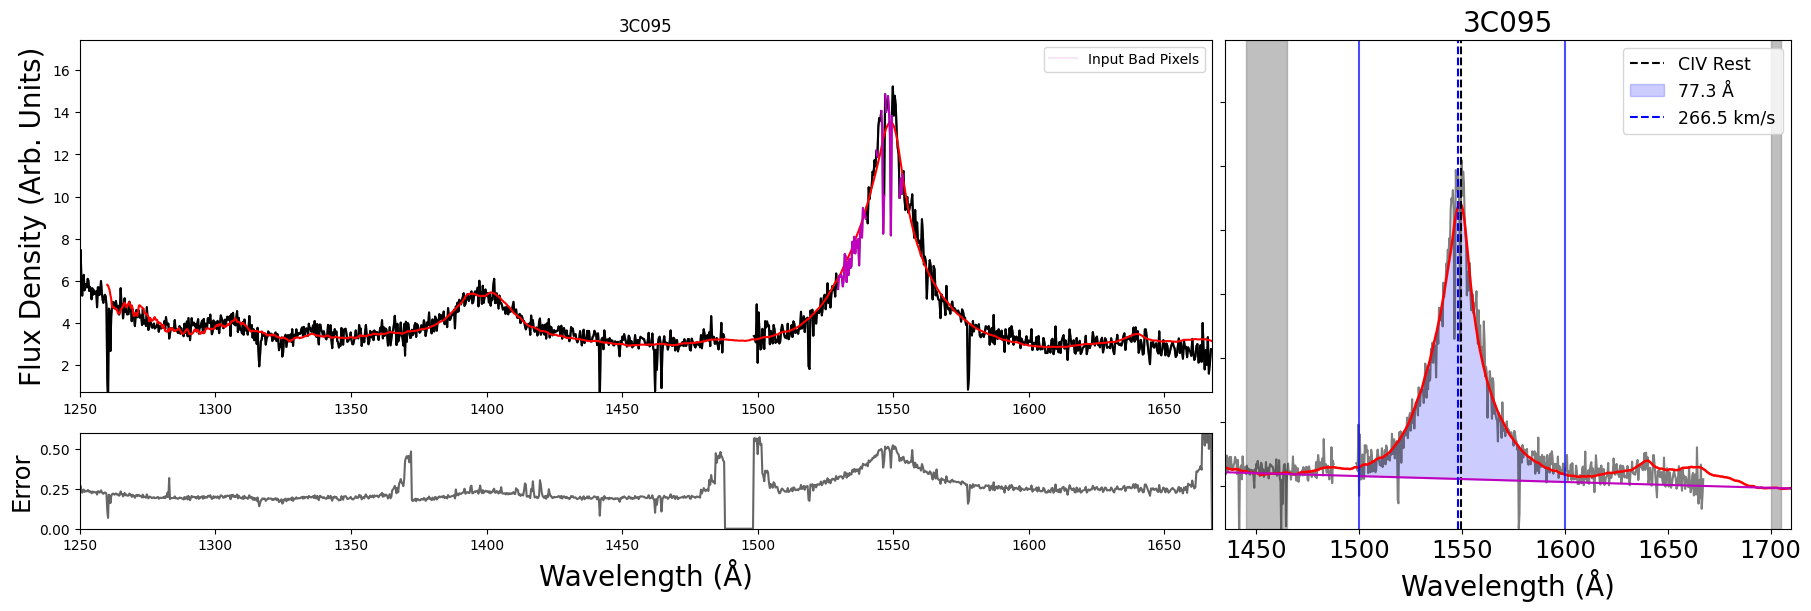

In [12]:
#----------------------Single Object Version----------------------------

wave_orig, flux_orig, z, errs_orig, mask_orig, name = setup('RBS1763')

comps_use = None

# print('before')

#filter_waves =  np.linspace(1546, 1555, 50)

#filter_waves= np.array([1546.5, 1546.75, 1547])


# filter_waves = np.array([1546.33, 1546.69, 1549.18])




bad_values = np.array([1544.20174858, 1545.98060034, 1546.33661651, 1546.69271467, 1547.40515702, 1548.47443591, 1548.83102638, 1549.18769896, 1549.54445368, 1552.75894544 , 1553.47418203])
filter_low = np.linspace(1530, 1540, 50)
#filter_high = np.linspace(1555, 1565, 50)

filter_waves = np.array(np.concatenate((filter_low, bad_values)))

mask_orig, indices  = custom_pix_filter(wave_orig, mask_orig, filter_waves)

print(indices)
print(flux_orig[indices])
print(wave_orig[indices])


wave_arb, flux_arb, errs_arb, mask_arb, wave_ica, flux_ica, f2500_ica = \
run_ICA_r20_components.main_ICA(wave_orig, flux_orig, errs_orig, mask_orig, z, name="", 
                                ica_path="", comps_use=comps_use)

# print('after')


c4mask = wave_arb>1400
ylow, yhigh = max(0, np.nanpercentile(flux_arb, 1)), np.nanpercentile(flux_arb[c4mask], 99)+np.nanmedian(flux_arb[c4mask])
ylow_err, yhigh_err = max(0, np.nanpercentile(errs_arb, 1)), np.nanpercentile(errs_arb, 99)
#xlow, xhigh = max(min(wave_arb), 1360), min(max(wave_arb), max(wave_ica))
xlow, xhigh = max(min(wave_arb), 1250), min(max(wave_arb), max(wave_ica))

fig = plt.figure(figsize=(18,6), constrained_layout=True)
gs  = GridSpec(4, 12, figure=fig)
ax1 = fig.add_subplot(gs[:3,:8]) #ica reconstruction
ax2 = fig.add_subplot(gs[:,8:])   #CIV fitting
ax3 = fig.add_subplot(gs[3,:8], sharex=ax1)
plt.subplots_adjust(hspace=0)

ax1.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax1.plot(wave_ica, flux_ica, "-r")

ax3.plot(wave_arb, errs_arb, "-k", alpha=0.6)

blue, ew = get_CIV(wave_arb, flux_arb, wave_ica, flux_ica, name_final, ax=ax2)

if name in CIV_BAL_regions.BAL_regions:
    for window in CIV_BAL_regions.BAL_regions[name]:
        ax1.axvspan(window[0], window[1], color="r", alpha=0.3)

plot_HST(wave_arb, flux_arb, mask_orig, ax1)

ax1.set_xlim(xlow, xhigh)
ax1.set_ylim(ylow, yhigh)
ax1.set_title(name_final)
ax3.set_xlim(xlow, xhigh)
ax3.set_ylim(ylow_err, yhigh_err)
ax1.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax3.set_xlabel("Wavelength (Å)", fontsize=20)
ax3.set_ylabel("Error", fontsize=17.5)
#plt.savefig("%s_%s_fullICA_wCIV_compsnone.png"%(name,inst))
plt.show()
#blue, EW = get_CIV(wave_orig, flux_orig, wave_reconst, reconstruction, name)
#dat.at[names==name,dat.columns=="CIV_blue_tvm"] = blue
#dat.at[names==name,dat.columns=="CIV_EW_tvm"]   = EW


In [79]:
wave_orig, flux_orig, z, errs_orig, mask_orig = setup('RBS1763')

ids = [x for x in range(1392, 1425)]
print(np.dstack((wave_orig[ids], np.round(flux_orig[ids] * 100))))

170
[[[1543.13542014  324.        ]
  [1543.49078111  316.        ]
  [1543.84622392  337.        ]
  [1544.20174858  329.        ]
  [1544.55735511  369.        ]
  [1544.91304353  380.        ]
  [1545.26881387  377.        ]
  [1545.62466613  389.        ]
  [1545.98060034  367.        ]
  [1546.33661651  228.        ]
  [1546.69271467  278.        ]
  [1547.04889483  412.        ]
  [1547.40515702  389.        ]
  [1547.76150125  396.        ]
  [1548.11792754  409.        ]
  [1548.47443591  393.        ]
  [1548.83102638  360.        ]
  [1549.18769896  226.        ]
  [1549.54445368  384.        ]
  [1549.90129056  423.        ]
  [1550.25820961  384.        ]
  [1550.61521086  411.        ]
  [1550.97229431  399.        ]
  [1551.32946     363.        ]
  [1551.68670794  343.        ]
  [1552.04403814  334.        ]
  [1552.40145064  277.        ]
  [1552.75894544  302.        ]
  [1553.11652256  282.        ]
  [1553.47418203  307.        ]
  [1553.83192387  312.        ]
  [1

1
[1393 1394 1395 1396 1397 1398 1399 1402 1404 1409 1410 1413 1415]
[2.86057878 2.63562106 3.06302044 3.335934   2.85728625 3.11505423
 3.61348336 4.16762143 4.87100395 4.90828686 5.09699708 4.54958274
 4.0301901 ]
[1543.71350682 1544.06900092 1544.42457688 1544.78023472 1545.13597447
 1545.49179614 1545.84769975 1546.91590242 1547.62844757 1549.41124673
 1549.76805293 1550.83896462 1551.55331683]
Function 'maskIterate' called get_ICA()
using mod EW components
Function 'main_ICA' called get_ICA()
using mod EW components
Function 'get_f2500' called get_ICA()
using mod EW components


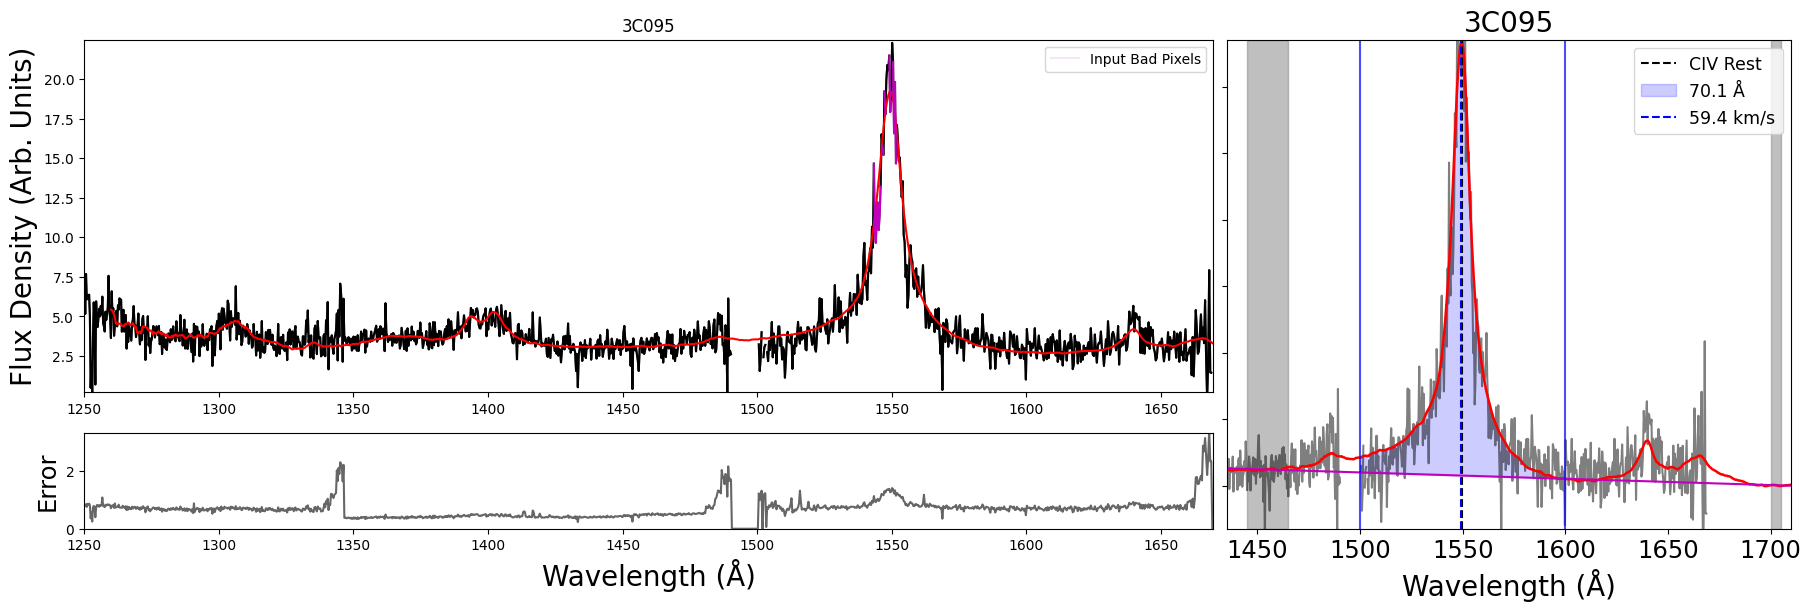

In [13]:
wave_orig, flux_orig, z, errs_orig, mask_orig, name = setup('1H1613-097')

comps_use = None

filter_low = np.linspace(1543.71350682, 1545.84769975, 100)

filter_waves = np.array([1546.91590242, 1547.62844757, 1549.41124673, 1549.76805293, 1550.8389646, 1551.55331683])

filter_waves = np.concatenate((filter_low, filter_waves))
mask_orig, indices  = custom_pix_filter(wave_orig, mask_orig, filter_waves)

print(indices)
print(flux_orig[indices])
print(wave_orig[indices])


wave_arb, flux_arb, errs_arb, mask_arb, wave_ica, flux_ica, f2500_ica = \
run_ICA_r20_components.main_ICA(wave_orig, flux_orig, errs_orig, mask_orig, z, name="", 
                                ica_path="", comps_use=comps_use)






c4mask = wave_arb>1400
ylow, yhigh = max(0, np.nanpercentile(flux_arb, 1)), np.nanpercentile(flux_arb[c4mask], 99)+np.nanmedian(flux_arb[c4mask])
ylow_err, yhigh_err = max(0, np.nanpercentile(errs_arb, 1)), np.nanpercentile(errs_arb, 99)
#xlow, xhigh = max(min(wave_arb), 1360), min(max(wave_arb), max(wave_ica))
xlow, xhigh = max(min(wave_arb), 1250), min(max(wave_arb), max(wave_ica))

fig = plt.figure(figsize=(18,6), constrained_layout=True)
#fig = plt.figure(figsize=(24,8), constrained_layout=True)


gs  = GridSpec(4, 12, figure=fig)
ax1 = fig.add_subplot(gs[:3,:8]) #ica reconstruction
ax2 = fig.add_subplot(gs[:,8:])   #CIV fitting
ax3 = fig.add_subplot(gs[3,:8], sharex=ax1)
plt.subplots_adjust(hspace=0)

ax1.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax1.plot(wave_ica, flux_ica, "-r")

ax3.plot(wave_arb, errs_arb, "-k", alpha=0.6)

blue, ew = get_CIV(wave_arb, flux_arb, wave_ica, flux_ica, name_final, ax=ax2)

if name in CIV_BAL_regions.BAL_regions:
    for window in CIV_BAL_regions.BAL_regions[name]:
        ax1.axvspan(window[0], window[1], color="r", alpha=0.3)


plot_HST(wave_arb, flux_arb, mask_orig, ax1)

ax1.set_xlim(xlow, xhigh)
ax1.set_ylim(ylow, yhigh)
ax1.set_title(name_final)
ax3.set_xlim(xlow, xhigh)
ax3.set_ylim(ylow_err, yhigh_err)
ax1.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax3.set_xlabel("Wavelength (Å)", fontsize=20)
ax3.set_ylabel("Error", fontsize=17.5)
#plt.savefig("%s_%s_fullICA_wCIV_compsnone.png"%(name,inst))
plt.show()
#blue, EW = get_CIV(wave_orig, flux_orig, wave_reconst, reconstruction, name)
#dat.at[names==name,dat.columns=="CIV_blue_tvm"] = blue
#dat.at[names==name,dat.columns=="CIV_EW_tvm"]   = EW


In [84]:
wave_orig, flux_orig, z, errs_orig, mask_orig = setup('1H1613-097')
ids = [x for x in range(1385, 1425)]
print(np.dstack((wave_orig[ids], np.round(flux_orig[ids] * 100))))

1
[[[1540.87249892  165.        ]
  [1541.22733878  212.        ]
  [1541.58226035  215.        ]
  [1541.93726365  254.        ]
  [1542.2923487   211.        ]
  [1542.64751553  291.        ]
  [1543.00276414  255.        ]
  [1543.35809457  400.        ]
  [1543.71350682  286.        ]
  [1544.06900092  264.        ]
  [1544.42457688  306.        ]
  [1544.78023472  334.        ]
  [1545.13597447  286.        ]
  [1545.49179614  312.        ]
  [1545.84769975  361.        ]
  [1546.20368532  452.        ]
  [1546.55975287  432.        ]
  [1546.91590242  417.        ]
  [1547.27213398  526.        ]
  [1547.62844757  487.        ]
  [1547.98484322  547.        ]
  [1548.34132094  572.        ]
  [1548.69788076  563.        ]
  [1549.05452268  588.        ]
  [1549.41124673  491.        ]
  [1549.76805293  510.        ]
  [1550.1249413   611.        ]
  [1550.48191186  578.        ]
  [1550.83896462  455.        ]
  [1551.1960996   543.        ]
  [1551.55331683  403.        ]
  [155

In [ ]:
[1546.91590242, 1547.62844757, 1549.41124673, 1549.76805293, 1550.8389646, 1551.55331683]

1
[1394 1395 1396 1397 1398 1399 1402 1404 1409 1410 1413 1415 1416 1417
 1418 1419 1420 1421 1422 1423 1424 1425 1426 1427 1428 1429 1430 1431
 1432 1433 1434 1435 1436 1437 1438 1439 1440 1441 1442 1443 1444 1445
 1446 1447]
[2.63562106 3.06302044 3.335934   2.85728625 3.11505423 3.61348336
 4.16762143 4.87100395 4.90828686 5.09699708 4.54958274 4.0301901
 4.69279662 4.43789705 4.06768768 4.13290181 3.70055035 3.444272
 3.72391736 2.79624606 2.66653569 2.05893584 2.2714267  1.52850806
 1.74213601 2.36739167 2.61941968 2.402832   2.33261342 1.90391138
 1.859448   2.18022627 2.21827419 1.72209543 2.07615022 1.77256903
 1.78125797 1.81462886 1.95876079 2.27769234 1.83404465 1.5780936
 1.18627862 1.53309617]
[1544.06900092 1544.42457688 1544.78023472 1545.13597447 1545.49179614
 1545.84769975 1546.91590242 1547.62844757 1549.41124673 1549.76805293
 1550.83896462 1551.55331683 1551.91061631 1552.26799808 1552.62546215
 1552.98300854 1553.34063726 1553.69834834 1554.0561418  1554.41401765


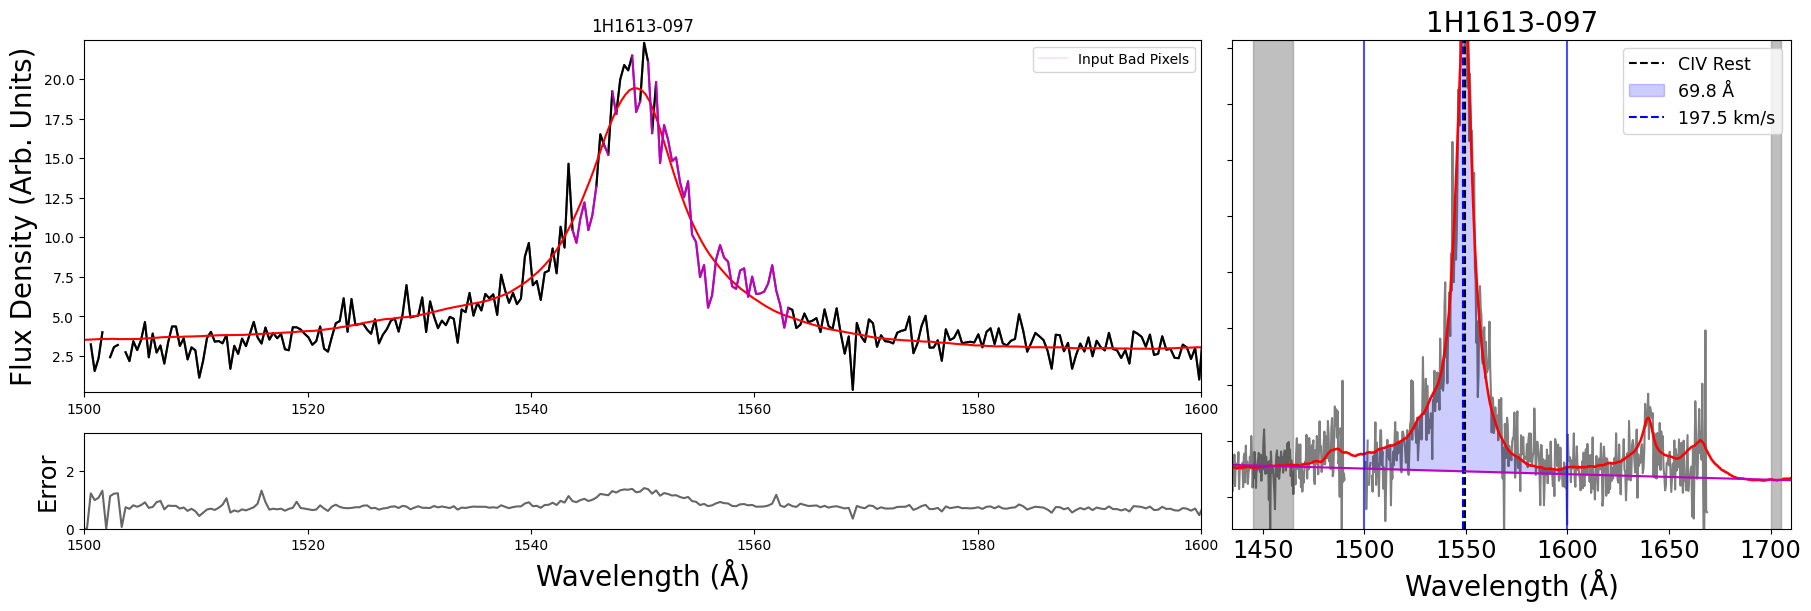

In [14]:
name_final = '1H1613-097'

wave_orig, flux_orig, z, errs_orig, mask_orig, name = setup(name_final)

comps_use = 'high'


filter_low = np.linspace(1543.71350682, 1545.84769975, 100)

filter_low = np.linspace(1544, 1545.84769975, 100)

filter_waves = np.array([1546.91590242, 1547.62844757, 1549.41124673, 1549.76805293, 1550.8389646, 1551.55331683])

filter_high = np.linspace(1552, 1563, 100)

filter_waves = np.concatenate((filter_low, filter_waves, filter_high))

mask_orig, indices  = custom_pix_filter(wave_orig, mask_orig, filter_waves)

print(indices)
print(flux_orig[indices])
print(wave_orig[indices])


wave_arb, flux_arb, errs_arb, mask_arb, wave_ica, flux_ica, f2500_ica = \
run_ICA_r20_components.main_ICA(wave_orig, flux_orig, errs_orig, mask_orig, z, name="", 
                                ica_path="", comps_use=comps_use)






c4mask = wave_arb>1400
ylow, yhigh = max(0, np.nanpercentile(flux_arb, 1)), np.nanpercentile(flux_arb[c4mask], 99)+np.nanmedian(flux_arb[c4mask])
ylow_err, yhigh_err = max(0, np.nanpercentile(errs_arb, 1)), np.nanpercentile(errs_arb, 99)
#xlow, xhigh = max(min(wave_arb), 1360), min(max(wave_arb), max(wave_ica))
xlow, xhigh = 1500 , 1600

fig = plt.figure(figsize=(18,6), constrained_layout=True)
#fig = plt.figure(figsize=(24,8), constrained_layout=True)


gs  = GridSpec(4, 12, figure=fig)
ax1 = fig.add_subplot(gs[:3,:8]) #ica reconstruction
ax2 = fig.add_subplot(gs[:,8:])   #CIV fitting
ax3 = fig.add_subplot(gs[3,:8], sharex=ax1)
plt.subplots_adjust(hspace=0)

ax1.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax1.plot(wave_ica, flux_ica, "-r")

ax3.plot(wave_arb, errs_arb, "-k", alpha=0.6)

blue, ew = get_CIV(wave_arb, flux_arb, wave_ica, flux_ica, name_final, ax=ax2)

if name_final in CIV_BAL_regions.BAL_regions:
    for window in CIV_BAL_regions.BAL_regions[name]:
        ax1.axvspan(window[0], window[1], color="r", alpha=0.3)


plot_HST(wave_arb, flux_arb, mask_orig, ax1)

ax1.set_xlim(xlow, xhigh)
ax1.set_ylim(ylow, yhigh)
ax1.set_title(name_final)
ax3.set_xlim(xlow, xhigh)
ax3.set_ylim(ylow_err, yhigh_err)
ax1.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax3.set_xlabel("Wavelength (Å)", fontsize=20)
ax3.set_ylabel("Error", fontsize=17.5)

#plt.savefig("%s_%s_fullICA_wCIV_compsnone.png"%(name,inst))
#plt.savefig('1H1613_097_mask_compshigh.png')

plt.show()
#blue, EW = get_CIV(wave_orig, flux_orig, wave_reconst, reconstruction, name)
#dat.at[names==name,dat.columns=="CIV_blue_tvm"] = blue
#dat.at[names==name,dat.columns=="CIV_EW_tvm"]   = EW



11
[1145 1290 1450 1690 1810 1955 2200 2660 2915 3550 4200 4720 5150 6125
 6850 7000]
[ 546  547  548  549  550  551  552  553  554  555  556  557  558  559
  560  561  562  563  564  565  566  567  568  569  570  571  572  573
  574  575  576  577  578  579  580  581  582  583  584  585  586  587
  588  589  590  591  592  593  594  595  596  597  598  599  600  601
  602  603  604  605  606  607  608  609  610  611  612  613  614  615
  616  617  618  619  620  621  622  623  624  625  626  627  628  629
  630  631  632  633  634  635  636  637  638  639  640  641  642  643
  644  645  646  647  648  649  650  651  652  653  654  655  656  657
  658  659  660  661  662  663  664  665  666  667  668  669  670  671
  672  673  674  675  676  677  678  679  680  681  682  683  684  685
  686  687  688  689  690  691  692  693  694  695  696  697  698  699
  700  701  702  703  704  705  706  707  708  709  710  711  712  713
  938  939  940  941  942  943  944  945  946  947  948  949  

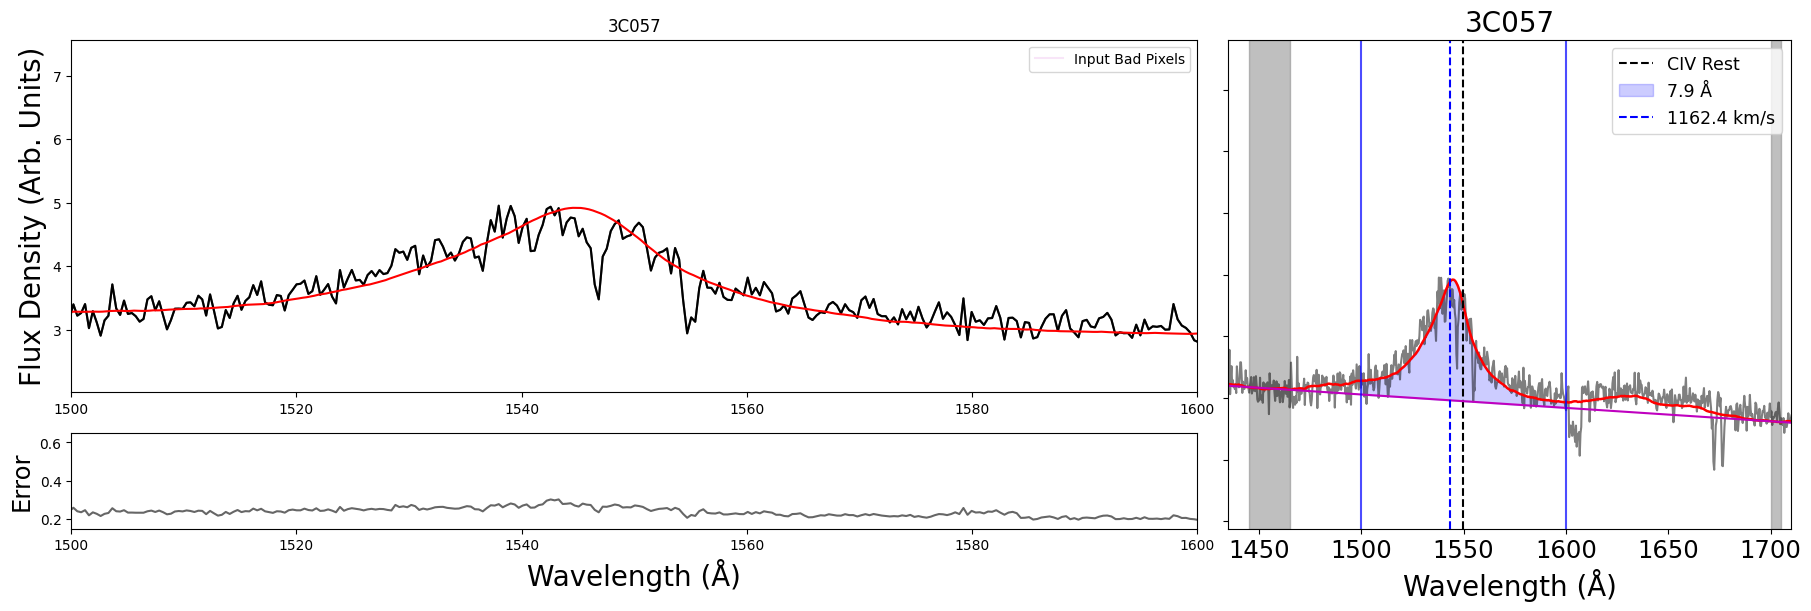

In [15]:
name_final = '3C057'

wave_orig, flux_orig, z, errs_orig, mask_orig, name = setup(name_final)

comps_use = None


filter_low = np.linspace(1880, 1900, 1000)
filter_2 = np.linspace(1390, 1440, 1000)
filter_3 = np.linspace(1270, 1320, 1000)
filter_waves = np.array([1546.12850417, 1546.4845544, 1546.84068663, 1547.19690087, 1554.33843728,1554.69637814,1555.05440143,1555.41250717, 1555.77069537])

filter_waves = np.concatenate((filter_low, filter_waves, filter_2, filter_3))

filter_waves = np.concatenate((filter_low, filter_2, filter_3))


mask_orig, indices  = custom_pix_filter(wave_orig, mask_orig, filter_waves)

print(indices)
print(flux_orig[indices])
print(wave_orig[indices])


wave_arb, flux_arb, errs_arb, mask_arb, wave_ica, flux_ica, f2500_ica = \
run_ICA_r20_components.main_ICA(wave_orig, flux_orig, errs_orig, mask_orig, z, name="", 
                                ica_path="", comps_use=comps_use)






c4mask = wave_arb>1400
ylow, yhigh = max(0, np.nanpercentile(flux_arb, 1)), np.nanpercentile(flux_arb[c4mask], 99)+np.nanmedian(flux_arb[c4mask])
ylow_err, yhigh_err = max(0, np.nanpercentile(errs_arb, 1)), np.nanpercentile(errs_arb, 99)
#xlow, xhigh = max(min(wave_arb), 1360), min(max(wave_arb), max(wave_ica))
xlow, xhigh = 1500 , 1600

fig = plt.figure(figsize=(18,6), constrained_layout=True)
#fig = plt.figure(figsize=(24,8), constrained_layout=True)


gs  = GridSpec(4, 12, figure=fig)
ax1 = fig.add_subplot(gs[:3,:8]) #ica reconstruction
ax2 = fig.add_subplot(gs[:,8:])   #CIV fitting
ax3 = fig.add_subplot(gs[3,:8], sharex=ax1)
plt.subplots_adjust(hspace=0)

ax1.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax1.plot(wave_ica, flux_ica, "-r")

ax3.plot(wave_arb, errs_arb, "-k", alpha=0.6)

blue, ew = get_CIV(wave_arb, flux_arb, wave_ica, flux_ica, name_final, ax=ax2)

if name in CIV_BAL_regions.BAL_regions:
    for window in CIV_BAL_regions.BAL_regions[name]:
        ax1.axvspan(window[0], window[1], color="r", alpha=0.3)


plot_HST(wave_arb, flux_arb, mask_orig, ax1)

ax1.set_xlim(xlow, xhigh)
ax1.set_ylim(ylow, yhigh)
ax1.set_title(name_final)
ax3.set_xlim(xlow, xhigh)
ax3.set_ylim(ylow_err, yhigh_err)
ax1.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax3.set_xlabel("Wavelength (Å)", fontsize=20)
ax3.set_ylabel("Error", fontsize=17.5)

#plt.savefig("%s_%s_fullICA_wCIV_compsnone.png"%(name,inst))
#plt.savefig('1H1613_097_mask_compshigh.png')

plt.show()
#blue, EW = get_CIV(wave_orig, flux_orig, wave_reconst, reconstruction, name)
#dat.at[names==name,dat.columns=="CIV_blue_tvm"] = blue
#dat.at[names==name,dat.columns=="CIV_EW_tvm"]   = EW



In [23]:
wave_orig, flux_orig, z, errs_orig, mask_orig = setup('3C057')
ids = [x for x in range(1385, 1440)]
print(np.dstack((wave_orig[ids], np.round(flux_orig[ids] * 100))))

11
[1145 1290 1450 1690 1810 1955 2200 2660 2915 3550 4200 4720 5150 6125
 6850 7000]
[[[1540.79757698  442.        ]
  [1541.15239959  443.        ]
  [1541.5073039   469.        ]
  [1541.86228994  485.        ]
  [1542.21735773  511.        ]
  [1542.57250729  515.        ]
  [1542.92773863  501.        ]
  [1543.28305177  513.        ]
  [1543.63844674  468.        ]
  [1543.99392356  489.        ]
  [1544.34948223  497.        ]
  [1544.70512278  495.        ]
  [1545.06084523  466.        ]
  [1545.4166496   478.        ]
  [1545.77253591  456.        ]
  [1546.12850417  446.        ]
  [1546.4845544   387.        ]
  [1546.84068663  362.        ]
  [1547.19690087  432.        ]
  [1547.55319714  445.        ]
  [1547.90957546  474.        ]
  [1548.26603585  486.        ]
  [1548.62257833  491.        ]
  [1548.97920291  461.        ]
  [1549.33590962  465.        ]
  [1549.69269847  467.        ]
  [1550.04956948  480.        ]
  [1550.40652268  487.        ]
  [1550.76355808  

11
[1145 1290 1450 1690 1810 1955 2200 2660 2915 3550 4200 4720 5150 6125
 6850 7000]
[ 647  648  649  650  651  652  653  654  655  656  657  658  659  660
  661  662  663  664  665  666  667  668  669  670  671  672  673  674
  675  676  677  678  679  680  681  682  683  684  685  686  687  688
  689  690  691  692  693  694  695  696  697  698  699  700  701  702
  703  704  705  706  707  708  709  710  711  712  713  938  939  940
  941  942  943  944  945  946  947  948  949  950  951  952  953  954
  955  956  957  958  959  960  961  962  963  964  965  966  967  968
  969  970  971  972  973  974  975  976  977  978  979  980  981  982
  983  984  985  986  987  988  989  990  991  992  993  994  995  996
  997  998  999 1000 1001 1002 1003 1004 1005 1006 1007 1008 1009 1010
 1011 1012 1013 1014 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024
 1025 1026 1027 1028 1029 1030 1031 1032 1033 1034 1035 1036 1037 1038
 1039 1040 1041 1042 1043 1044 1045 1046 1047 1048 1049 1050 1

<Figure size 1800x600 with 0 Axes>

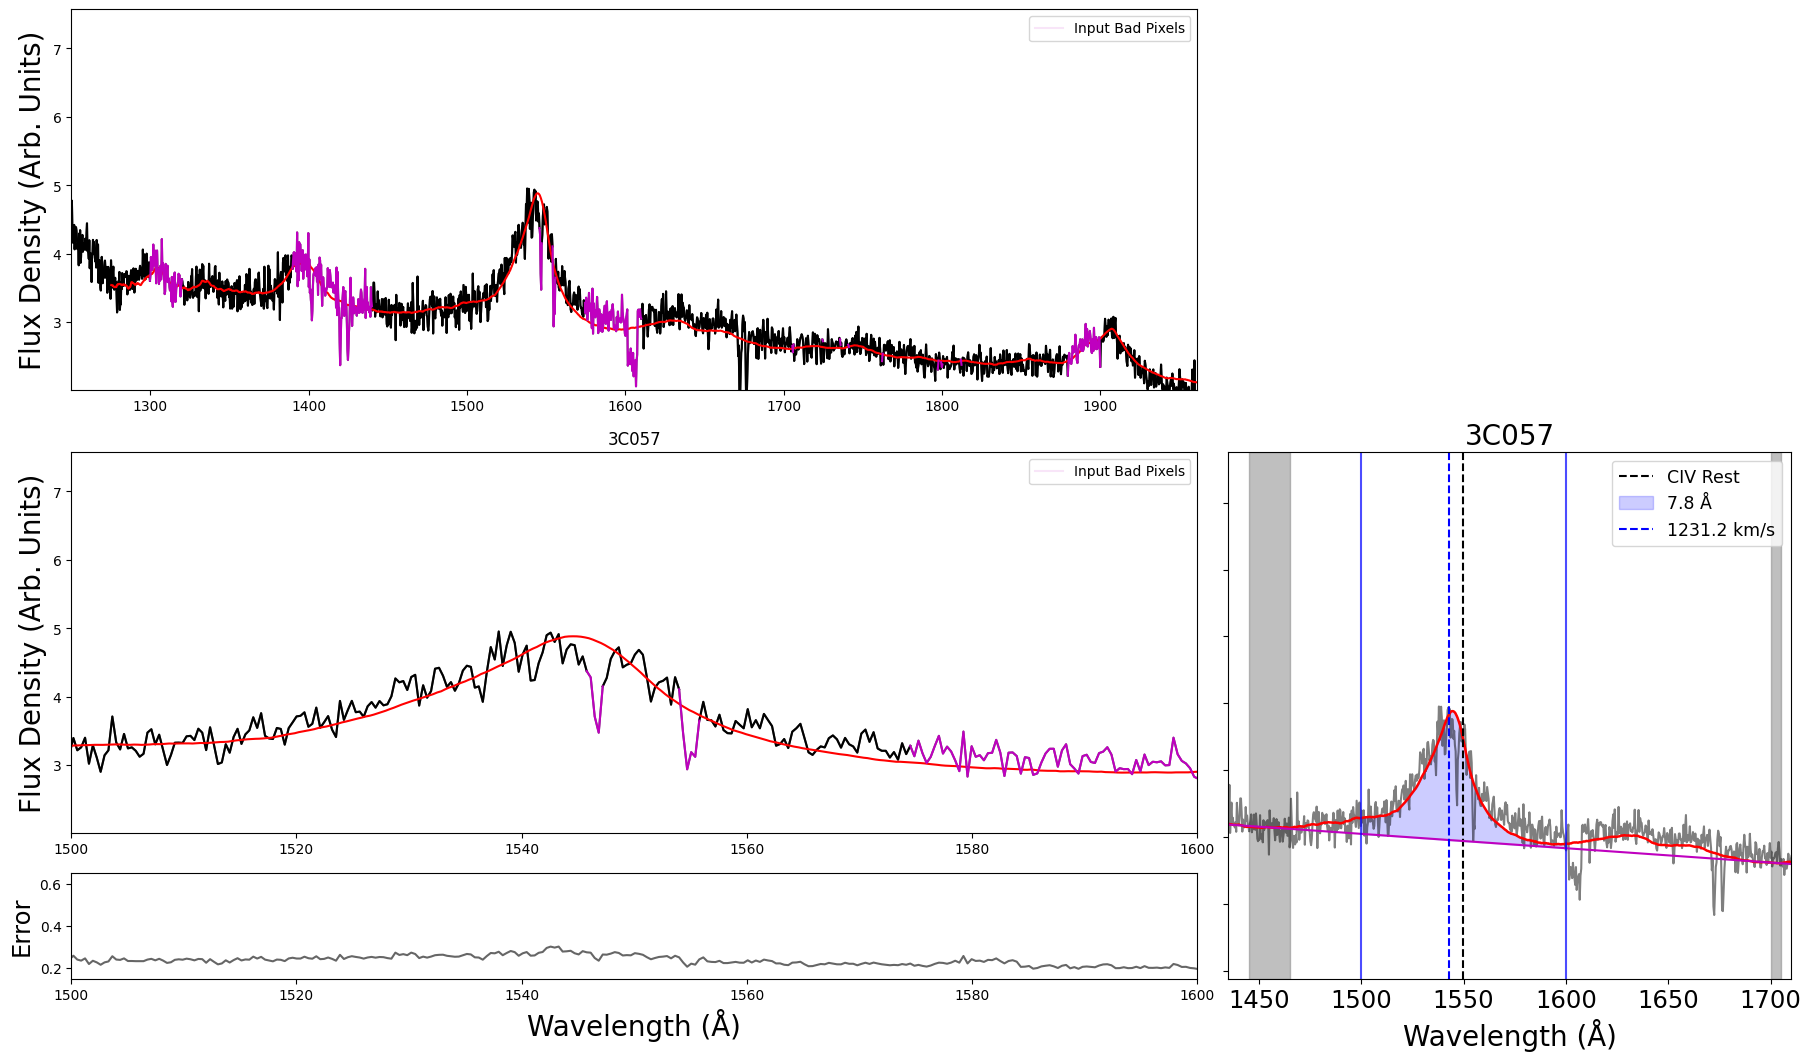

In [16]:
name_final = '3C057'

wave_orig, flux_orig, z, errs_orig, mask_orig, name = setup(name_final)

comps_use = None


filter_low = np.linspace(1880, 1900, 1000)
filter_2 = np.linspace(1390, 1440, 1000)
filter_3 = np.linspace(1300, 1320, 1000)
filter_4 = np.linspace(1575, 1610, 1000)
filter_waves = np.array([1546.12850417, 1546.4845544, 1546.84068663, 1547.19690087, 1554.33843728,1554.69637814,1555.05440143,1555.41250717, 1555.77069537])

filter_waves = np.concatenate((filter_low, filter_waves, filter_2, filter_3, filter_4))

#filter_waves = np.concatenate((filter_low, filter_2, filter_3))


mask_orig, indices  = custom_pix_filter(wave_orig, mask_orig, filter_waves)

print(indices)
print(flux_orig[indices])
print(wave_orig[indices])


wave_arb, flux_arb, errs_arb, mask_arb, wave_ica, flux_ica, f2500_ica = \
run_ICA_r20_components.main_ICA(wave_orig, flux_orig, errs_orig, mask_orig, z, name="", 
                                ica_path="", comps_use=comps_use)






c4mask = wave_arb>1400
ylow, yhigh = max(0, np.nanpercentile(flux_arb, 1)), np.nanpercentile(flux_arb[c4mask], 99)+np.nanmedian(flux_arb[c4mask])
ylow_err, yhigh_err = max(0, np.nanpercentile(errs_arb, 1)), np.nanpercentile(errs_arb, 99)
#xlow, xhigh = max(min(wave_arb), 1360), min(max(wave_arb), max(wave_ica))
xlow, xhigh = 1500 , 1600
xlow0, xhigh0 = max(min(wave_arb), 1250), min(max(wave_arb), max(wave_ica))

fig = plt.figure(figsize=(18,6), constrained_layout=True)
fig = plt.figure(figsize=(18,10.5), constrained_layout=True)


gs  = GridSpec(7, 12, figure=fig)

ax0 = fig.add_subplot(gs[:3,:8])
ax1 = fig.add_subplot(gs[3:6,:8]) #ica reconstruction
ax2 = fig.add_subplot(gs[3:,8:])   #CIV fitting
ax3 = fig.add_subplot(gs[6,:8], sharex=ax1)
plt.subplots_adjust(hspace=0)

ax0.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax0.plot(wave_ica, flux_ica, "-r")

ax1.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax1.plot(wave_ica, flux_ica, "-r")

ax3.plot(wave_arb, errs_arb, "-k", alpha=0.6)

blue, ew = get_CIV(wave_arb, flux_arb, wave_ica, flux_ica, name_final, ax=ax2)

if name in CIV_BAL_regions.BAL_regions:
    for window in CIV_BAL_regions.BAL_regions[name]:
        ax1.axvspan(window[0], window[1], color="r", alpha=0.3)

plot_HST(wave_arb, flux_arb, mask_orig, ax0)
plot_HST(wave_arb, flux_arb, mask_orig, ax1)

ax0.set_xlim(xlow0, xhigh0)
ax0.set_ylim(ylow, yhigh)

ax1.set_xlim(xlow, xhigh)
ax1.set_ylim(ylow, yhigh)
ax1.set_title(name_final)
ax3.set_xlim(xlow, xhigh)
ax3.set_ylim(ylow_err, yhigh_err)
ax0.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax1.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax3.set_xlabel("Wavelength (Å)", fontsize=20)
ax3.set_ylabel("Error", fontsize=17.5)

#plt.savefig("%s_%s_fullICA_wCIV_compsnone.png"%(name,inst))
#plt.savefig('New_ICA_Plots//3C057_mask_compsnone.png')

plt.show()

12
Function 'maskIterate' called get_ICA()
using mod EW components
Function 'main_ICA' called get_ICA()
using mod EW components
Function 'get_f2500' called get_ICA()
using mod EW components


<Figure size 1800x600 with 0 Axes>

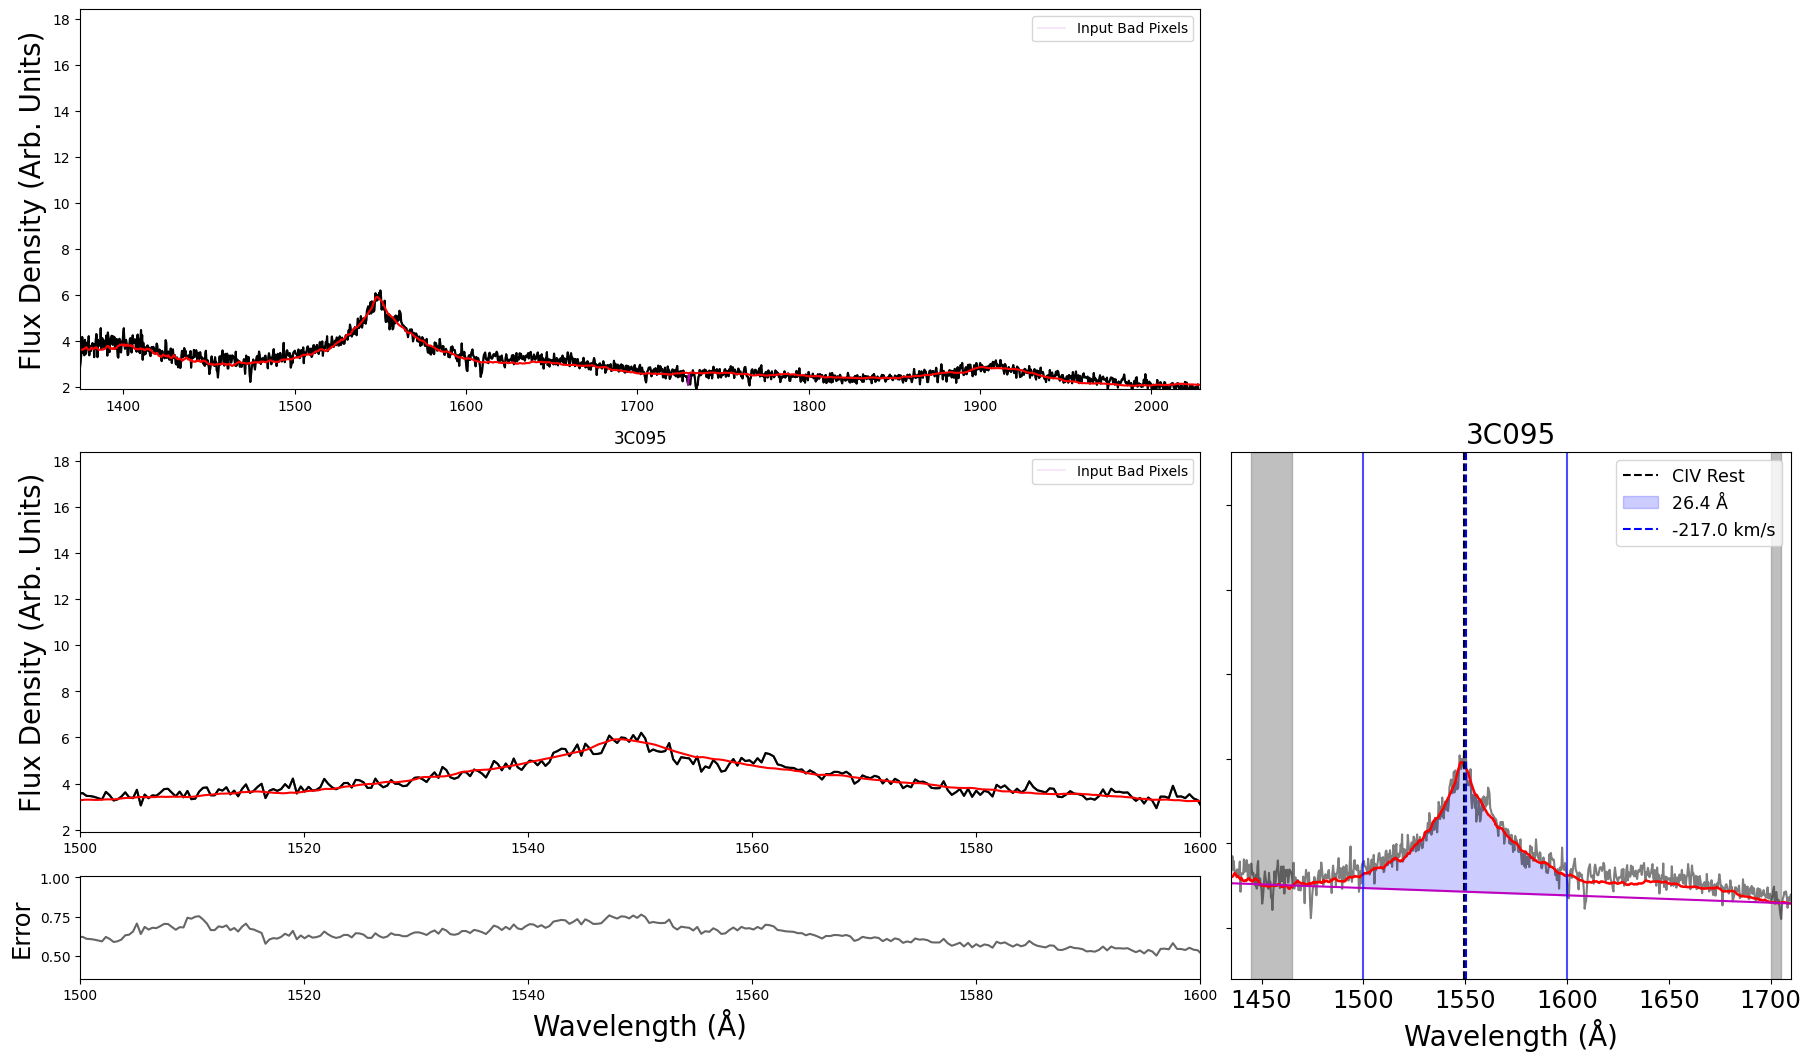

In [28]:
name_final = '3C095'

wave_orig, flux_orig, z, errs_orig, mask_orig, name = setup(name_final)

comps_use = None

wave_arb, flux_arb, errs_arb, mask_arb, wave_ica, flux_ica, f2500_ica = \
run_ICA_r20_components.main_ICA(wave_orig, flux_orig, errs_orig, mask_orig, z, name="", 
                                ica_path="", comps_use=comps_use)

c4mask = wave_arb>1400
ylow, yhigh = max(0, np.nanpercentile(flux_arb, 1)), np.nanpercentile(flux_arb[c4mask], 99)+np.nanmedian(flux_arb[c4mask])
ylow_err, yhigh_err = max(0, np.nanpercentile(errs_arb, 1)), np.nanpercentile(errs_arb, 99)
#xlow, xhigh = max(min(wave_arb), 1360), min(max(wave_arb), max(wave_ica))
xlow, xhigh = 1500 , 1600
xlow0, xhigh0 = max(min(wave_arb), 1250), min(max(wave_arb), max(wave_ica))

fig = plt.figure(figsize=(18,6), constrained_layout=True)
fig = plt.figure(figsize=(18,10.5), constrained_layout=True)


gs  = GridSpec(7, 12, figure=fig)

ax0 = fig.add_subplot(gs[:3,:8])
ax1 = fig.add_subplot(gs[3:6,:8]) #ica reconstruction
ax2 = fig.add_subplot(gs[3:,8:])   #CIV fitting
ax3 = fig.add_subplot(gs[6,:8], sharex=ax1)
plt.subplots_adjust(hspace=0)

ax0.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax0.plot(wave_ica, flux_ica, "-r")

ax1.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax1.plot(wave_ica, flux_ica, "-r")

ax3.plot(wave_arb, errs_arb, "-k", alpha=0.6)

blue, ew = get_CIV(wave_arb, flux_arb, wave_ica, flux_ica, name_final, ax=ax2)

if name in CIV_BAL_regions.BAL_regions:
    for window in CIV_BAL_regions.BAL_regions[name]:
        ax1.axvspan(window[0], window[1], color="r", alpha=0.3)

plot_HST(wave_arb, flux_arb, mask_orig, ax0)
plot_HST(wave_arb, flux_arb, mask_orig, ax1)

ax0.set_xlim(xlow0, xhigh0)
ax0.set_ylim(ylow, yhigh+10)

ax1.set_xlim(xlow, xhigh)
ax1.set_ylim(ylow, yhigh+10)
ax1.set_title(name_final)
ax3.set_xlim(xlow, xhigh)
ax3.set_ylim(ylow_err, yhigh_err)
ax0.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax1.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax3.set_xlabel("Wavelength (Å)", fontsize=20)
ax3.set_ylabel("Error", fontsize=17.5)

#plt.savefig("%s_%s_fullICA_wCIV_compsnone.png"%(name,inst))
plt.savefig('New_ICA_Plots//Good//3C095_nomask_compsnone.png')

plt.show()

13
[1145 1290 1450 1690 1810 1845 2200 2660 2915 3550 4200 4720 5150 6125
 6850 7000]
[1481 1482 1483 1484 1492 1493 1494 1495 1496]
[3.47139183 3.10207243 3.22107271 4.19023443 3.61413273 2.8885272
 3.12060623 3.74090009 3.85772132]
[1575.24631086 1575.60906649 1575.97190566 1576.33482838 1579.24122051
 1579.60489611 1579.96865545 1580.33249857 1580.69642547]
Function 'maskIterate' called get_ICA()
using high EW components
Function 'main_ICA' called get_ICA()
using high EW components
Function 'get_f2500' called get_ICA()
using high EW components


<Figure size 1800x600 with 0 Axes>

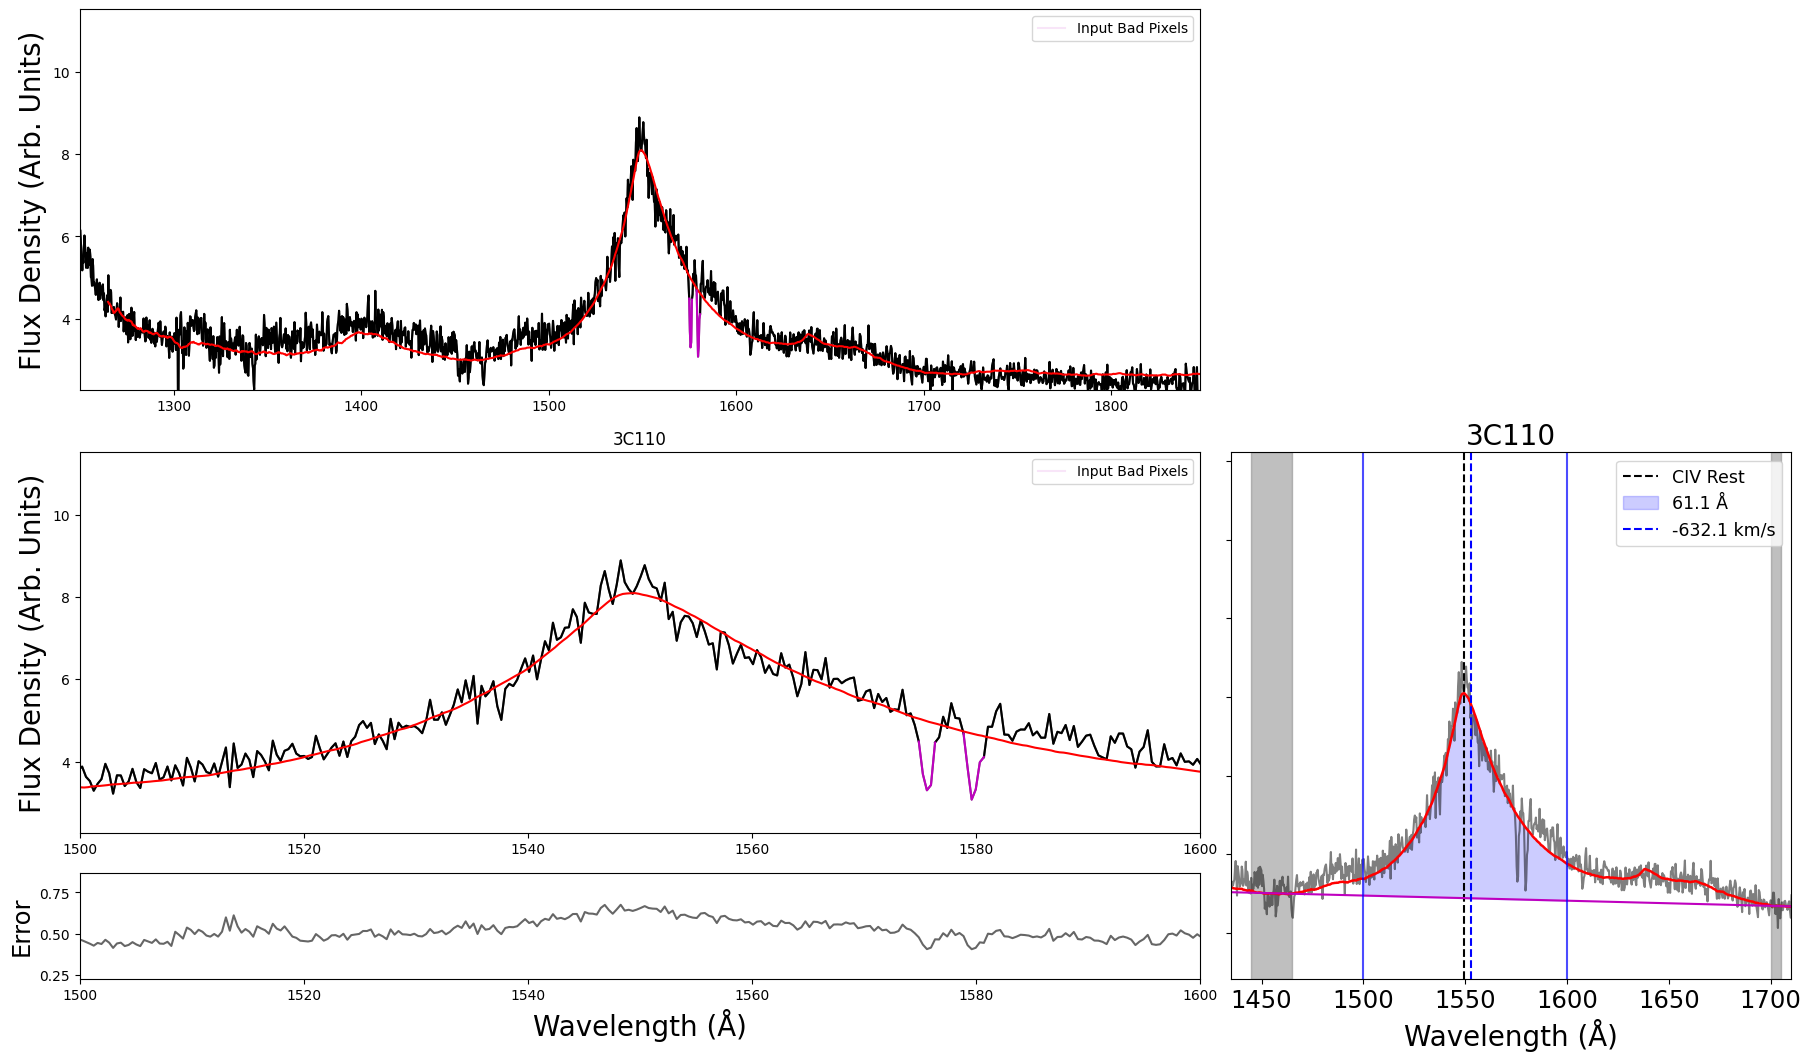

In [21]:
name_final = '3C110'

wave_orig, flux_orig, z, errs_orig, mask_orig, name = setup(name_final)

comps_use = None


# filter_low = np.linspace(1880, 1900, 1000)
# filter_2 = np.linspace(1390, 1440, 1000)
# filter_3 = np.linspace(1300, 1320, 1000)
# filter_4 = np.linspace(1575, 1610, 1000)
filter_waves = np.array([1575.24631086, 1575.60906649, 1575.9719056, 1576.33482838, 1579.24122051, 1579.60489611, 1579.96865545, 1580.33249857,1580.69642547])

# filter_waves = np.concatenate((filter_low, filter_waves, filter_2, filter_3, filter_4))

#filter_waves = np.concatenate((filter_low, filter_2, filter_3))


mask_orig, indices  = custom_pix_filter(wave_orig, mask_orig, filter_waves)

print(indices)
print(flux_orig[indices])
print(wave_orig[indices])


wave_arb, flux_arb, errs_arb, mask_arb, wave_ica, flux_ica, f2500_ica = \
run_ICA_r20_components.main_ICA(wave_orig, flux_orig, errs_orig, mask_orig, z, name="", 
                                ica_path="", comps_use=comps_use)






c4mask = wave_arb>1400
ylow, yhigh = max(0, np.nanpercentile(flux_arb, 1)), np.nanpercentile(flux_arb[c4mask], 99)+np.nanmedian(flux_arb[c4mask])
ylow_err, yhigh_err = max(0, np.nanpercentile(errs_arb, 1)), np.nanpercentile(errs_arb, 99)
#xlow, xhigh = max(min(wave_arb), 1360), min(max(wave_arb), max(wave_ica))
xlow, xhigh = 1500 , 1600
xlow0, xhigh0 = max(min(wave_arb), 1250), min(max(wave_arb), max(wave_ica))

fig = plt.figure(figsize=(18,6), constrained_layout=True)
fig = plt.figure(figsize=(18,10.5), constrained_layout=True)


gs  = GridSpec(7, 12, figure=fig)

ax0 = fig.add_subplot(gs[:3,:8])
ax1 = fig.add_subplot(gs[3:6,:8]) #ica reconstruction
ax2 = fig.add_subplot(gs[3:,8:])   #CIV fitting
ax3 = fig.add_subplot(gs[6,:8], sharex=ax1)
plt.subplots_adjust(hspace=0)

ax0.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax0.plot(wave_ica, flux_ica, "-r")

ax1.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax1.plot(wave_ica, flux_ica, "-r")

ax3.plot(wave_arb, errs_arb, "-k", alpha=0.6)

blue, ew = get_CIV(wave_arb, flux_arb, wave_ica, flux_ica, name_final, ax=ax2)

if name in CIV_BAL_regions.BAL_regions:
    for window in CIV_BAL_regions.BAL_regions[name]:
        ax1.axvspan(window[0], window[1], color="r", alpha=0.3)

plot_HST(wave_arb, flux_arb, mask_orig, ax0)
plot_HST(wave_arb, flux_arb, mask_orig, ax1)

ax0.set_xlim(xlow0, xhigh0)
ax0.set_ylim(ylow, yhigh)

ax1.set_xlim(xlow, xhigh)
ax1.set_ylim(ylow, yhigh)
ax1.set_title(name_final)
ax3.set_xlim(xlow, xhigh)
ax3.set_ylim(ylow_err, yhigh_err)
ax0.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax1.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax3.set_xlabel("Wavelength (Å)", fontsize=20)
ax3.set_ylabel("Error", fontsize=17.5)

#plt.savefig("%s_%s_fullICA_wCIV_compsnone.png"%(name,inst))
plt.savefig('New_ICA_Plots//Good//3C110_mask_compsnone.png')

plt.show()

In [54]:
wave_orig, flux_orig, z, errs_orig, mask_orig = setup('3C110')
ids = [x for x in range(1475, 1500)]
print(np.dstack((wave_orig[ids], np.round(flux_orig[ids] * 100))))

13
[1145 1290 1450 1690 1810 1845 2200 2660 2915 3550 4200 4720 5150 6125
 6850 7000]
[[[1573.07153029  494.        ]
  [1573.4337851   540.        ]
  [1573.79612333  481.        ]
  [1574.15854501  486.        ]
  [1574.52105014  459.        ]
  [1574.88363875  421.        ]
  [1575.24631086  347.        ]
  [1575.60906649  310.        ]
  [1575.97190566  322.        ]
  [1576.33482838  419.        ]
  [1576.69783468  431.        ]
  [1577.06092457  478.        ]
  [1577.42409808  452.        ]
  [1577.78735522  509.        ]
  [1578.15069602  475.        ]
  [1578.51412048  474.        ]
  [1578.87762864  440.        ]
  [1579.24122051  361.        ]
  [1579.60489611  289.        ]
  [1579.96865545  312.        ]
  [1580.33249857  374.        ]
  [1580.69642547  386.        ]
  [1581.06043618  455.        ]
  [1581.42453071  455.        ]
  [1581.78870909  490.        ]]]


28
3C390 is in CIV_BAL_regions
[1340 1341 1342 1343 1344 1345 1346 1347 1348 1349 1350 1351 1352 1353
 1354 1355 1356 1357 1358 1359 1360 1361 1362 1363 1364 1365 1366 1367
 1368 1369 1370 1371 1372 1373 1374 1375 1376 1377 1378 1379 1380 1381
 1382 1383]
[3.3372904  4.73867021 6.53496357 5.5069822  5.66026516 4.96073095
 6.24253371 4.96443487 6.46627164 4.8508245  5.55730953 6.32711791
 6.56153644 5.70287015 6.68933868 6.01542212 5.35490949 5.79401585
 6.65302436 5.73798274 6.26172394 6.55033281 4.84038026 6.37631724
 6.7730771  6.7969478  6.36869157 7.18991254 5.42099238 4.66772334
 5.48887967 6.06432366 6.78151111 5.72236533 6.10425181 5.37679929
 5.68299416 6.10682231 5.98364121 6.40533529 5.56682609 5.51199778
 6.05115025 5.7187587 ]
[1524.90139723 1525.25255918 1525.603802   1525.9551257  1526.30653031
 1526.65801584 1527.00958231 1527.36122975 1527.71295816 1528.06476757
 1528.416658   1528.76862946 1529.12068198 1529.47281556 1529.82503024
 1530.17732603 1530.52970295 1530.8821

<Figure size 1800x600 with 0 Axes>

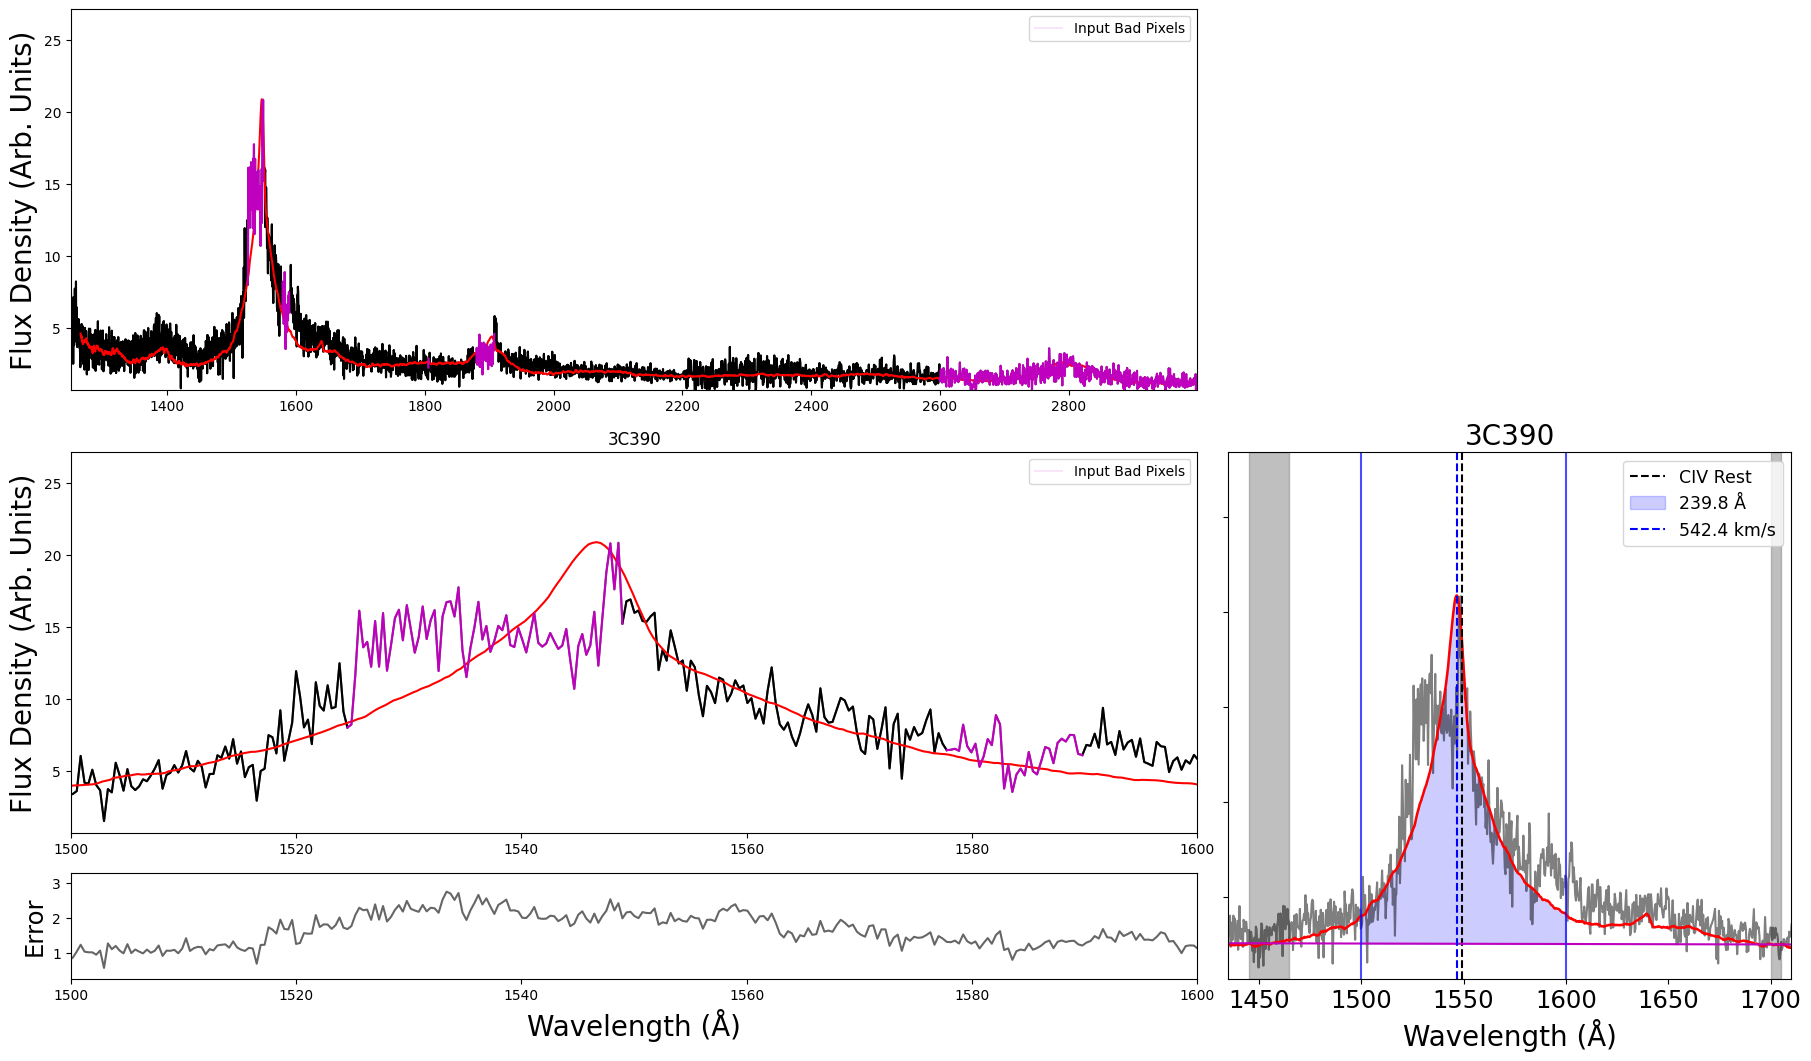

In [76]:
name_final = '3C390'

wave_orig, flux_orig, z, errs_orig, mask_orig = setup(name_final)

comps_use = 'high'


filter_waves = np.linspace(1525, 1540, 1000)
# filter_2 = np.linspace(1390, 1440, 1000)
# filter_3 = np.linspace(1300, 1320, 1000)
# filter_4 = np.linspace(1575, 1610, 1000)

#filter_waves = np.array([1575.24631086, 1575.60906649, 1575.9719056, 1576.33482838, 1579.24122051, 1579.60489611, 1579.96865545, 1580.33249857,1580.69642547])

# filter_waves = np.concatenate((filter_low, filter_waves, filter_2, filter_3, filter_4))

#filter_waves = np.concatenate((filter_low, filter_2, filter_3))


mask_orig, indices  = custom_pix_filter(wave_orig, mask_orig, filter_waves)

print(indices)
print(flux_orig[indices])
print(wave_orig[indices])


wave_arb, flux_arb, errs_arb, mask_arb, wave_ica, flux_ica, f2500_ica = \
run_ICA_r20_components.main_ICA(wave_orig, flux_orig, errs_orig, mask_orig, z, name="", 
                                ica_path="", comps_use=comps_use)






c4mask = wave_arb>1400
ylow, yhigh = max(0, np.nanpercentile(flux_arb, 1)), np.nanpercentile(flux_arb[c4mask], 99)+np.nanmedian(flux_arb[c4mask])
ylow_err, yhigh_err = max(0, np.nanpercentile(errs_arb, 1)), np.nanpercentile(errs_arb, 99)
#xlow, xhigh = max(min(wave_arb), 1360), min(max(wave_arb), max(wave_ica))
xlow, xhigh = 1500 , 1600
xlow0, xhigh0 = max(min(wave_arb), 1250), min(max(wave_arb), max(wave_ica))

fig = plt.figure(figsize=(18,6), constrained_layout=True)
fig = plt.figure(figsize=(18,10.5), constrained_layout=True)


gs  = GridSpec(7, 12, figure=fig)

ax0 = fig.add_subplot(gs[:3,:8])
ax1 = fig.add_subplot(gs[3:6,:8]) #ica reconstruction
ax2 = fig.add_subplot(gs[3:,8:])   #CIV fitting
ax3 = fig.add_subplot(gs[6,:8], sharex=ax1)
plt.subplots_adjust(hspace=0)

ax0.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax0.plot(wave_ica, flux_ica, "-r")

ax1.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax1.plot(wave_ica, flux_ica, "-r")

ax3.plot(wave_arb, errs_arb, "-k", alpha=0.6)

blue, ew = get_CIV(wave_arb, flux_arb, wave_ica, flux_ica, name_final, ax=ax2)

if name in CIV_BAL_regions.BAL_regions:
    for window in CIV_BAL_regions.BAL_regions[name]:
        ax1.axvspan(window[0], window[1], color="r", alpha=0.3)

plot_HST(wave_arb, flux_arb, mask_orig, ax0)
plot_HST(wave_arb, flux_arb, mask_orig, ax1)

ax0.set_xlim(xlow0, xhigh0)
ax0.set_ylim(ylow, yhigh+10)

ax1.set_xlim(xlow, xhigh)
ax1.set_ylim(ylow, yhigh+10)
ax1.set_title(name_final)
ax3.set_xlim(xlow, xhigh)
ax3.set_ylim(ylow_err, yhigh_err)
ax0.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax1.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax3.set_xlabel("Wavelength (Å)", fontsize=20)
ax3.set_ylabel("Error", fontsize=17.5)

#plt.savefig("%s_%s_fullICA_wCIV_compsnone.png"%(name,inst))
#plt.savefig('New_ICA_Plots//3C390_mask_compshigh.png')

plt.show()

14
3C207 is in CIV_BAL_regions
Function 'maskIterate' called get_ICA()
using mod EW components
Function 'main_ICA' called get_ICA()
using mod EW components


<Figure size 1800x600 with 0 Axes>

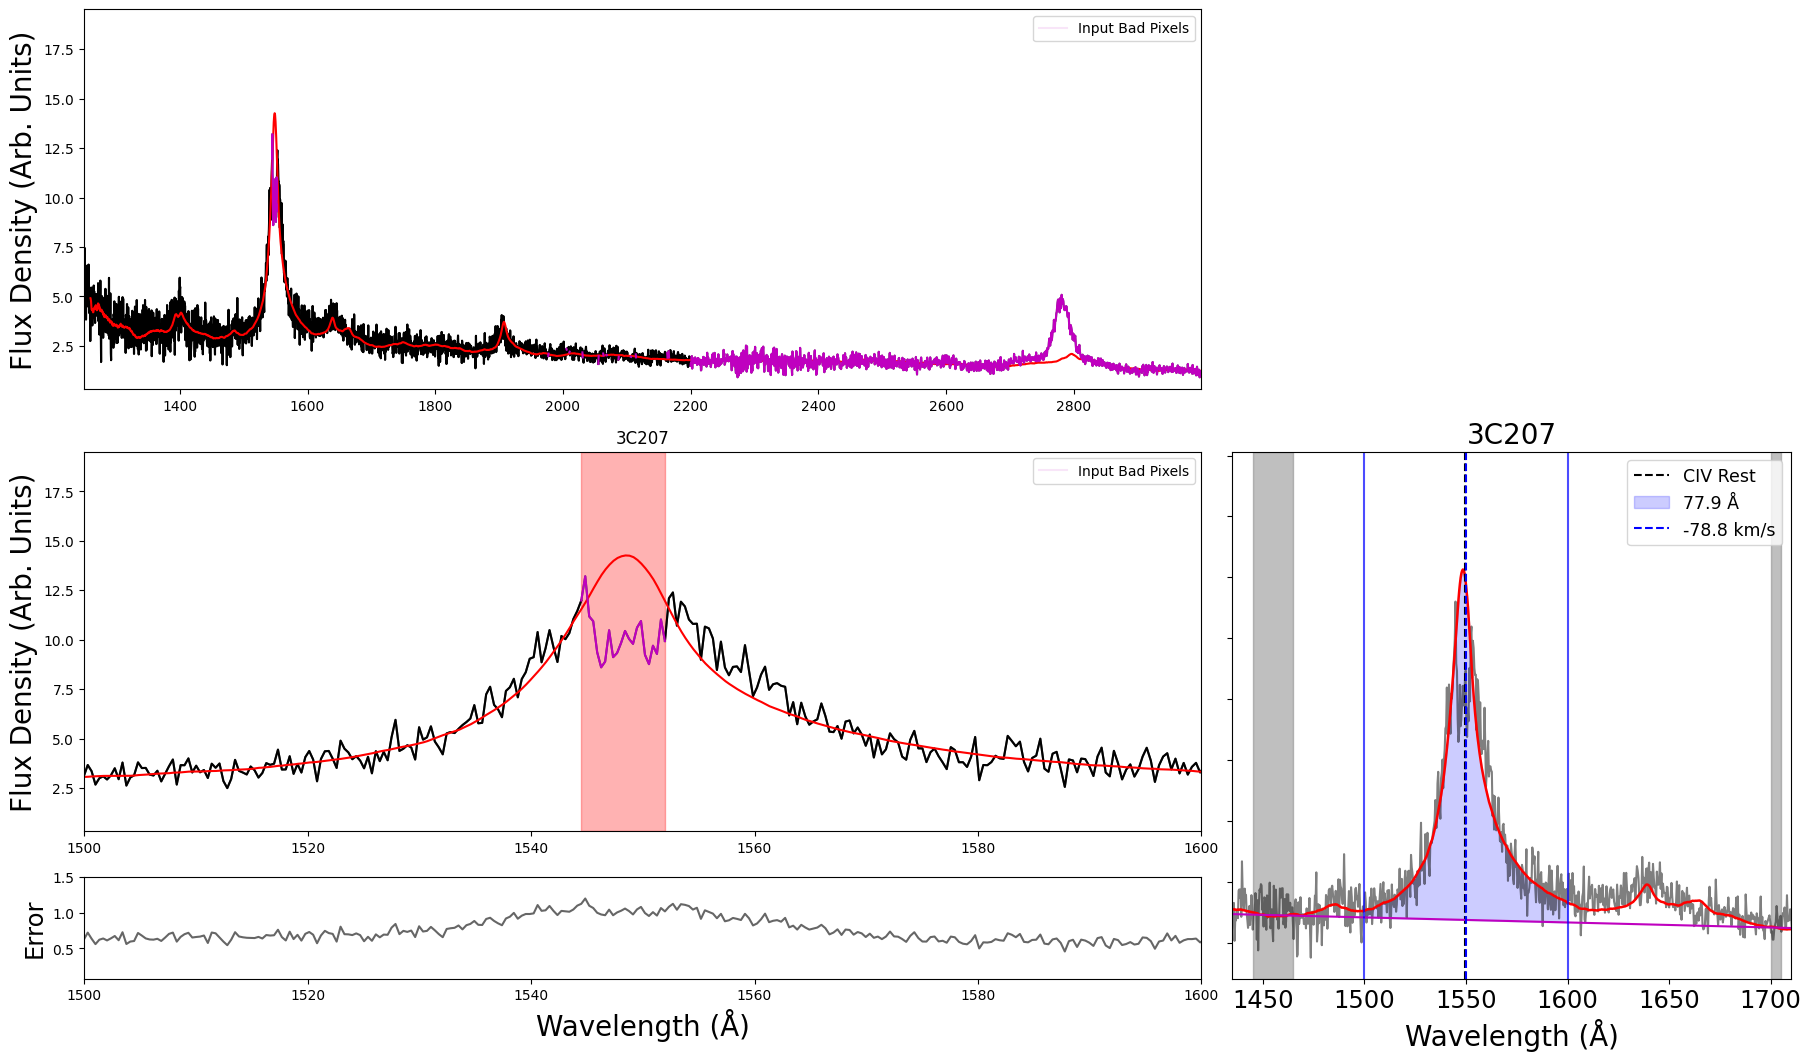

In [27]:
name_final = '3C207'

wave_orig, flux_orig, z, errs_orig, mask_orig, name = setup(name_final)

comps_use = None 

wave_arb, flux_arb, errs_arb, mask_arb, wave_ica, flux_ica, f2500_ica = \
run_ICA_r20_components.main_ICA(wave_orig, flux_orig, errs_orig, mask_orig, z, name="", 
                                ica_path="", comps_use=comps_use)

c4mask = wave_arb>1400
ylow, yhigh = max(0, np.nanpercentile(flux_arb, 1)), np.nanpercentile(flux_arb[c4mask], 99)+np.nanmedian(flux_arb[c4mask])
ylow_err, yhigh_err = max(0, np.nanpercentile(errs_arb, 1)), np.nanpercentile(errs_arb, 99)
#xlow, xhigh = max(min(wave_arb), 1360), min(max(wave_arb), max(wave_ica))
xlow, xhigh = 1500 , 1600
xlow0, xhigh0 = max(min(wave_arb), 1250), min(max(wave_arb), max(wave_ica))

fig = plt.figure(figsize=(18,6), constrained_layout=True)
fig = plt.figure(figsize=(18,10.5), constrained_layout=True)


gs  = GridSpec(7, 12, figure=fig)

ax0 = fig.add_subplot(gs[:3,:8])
ax1 = fig.add_subplot(gs[3:6,:8]) #ica reconstruction
ax2 = fig.add_subplot(gs[3:,8:])   #CIV fitting
ax3 = fig.add_subplot(gs[6,:8], sharex=ax1)
plt.subplots_adjust(hspace=0)

ax0.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax0.plot(wave_ica, flux_ica, "-r")

ax1.plot(wave_arb, flux_arb, "-k", alpha=0.6)
ax1.plot(wave_ica, flux_ica, "-r")

ax3.plot(wave_arb, errs_arb, "-k", alpha=0.6)

blue, ew = get_CIV(wave_arb, flux_arb, wave_ica, flux_ica, name_final, ax=ax2)

if name in CIV_BAL_regions.BAL_regions:
    for window in CIV_BAL_regions.BAL_regions[name]:
        ax1.axvspan(window[0], window[1], color="r", alpha=0.3)

plot_HST(wave_arb, flux_arb, mask_orig, ax0)
plot_HST(wave_arb, flux_arb, mask_orig, ax1)

ax0.set_xlim(xlow0, xhigh0)
ax0.set_ylim(ylow, yhigh+10)

ax1.set_xlim(xlow, xhigh)
ax1.set_ylim(ylow, yhigh+10)
ax1.set_title(name_final)
ax3.set_xlim(xlow, xhigh)
ax3.set_ylim(ylow_err, yhigh_err)
ax0.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax1.set_ylabel("Flux Density (Arb. Units)", fontsize=20)
ax3.set_xlabel("Wavelength (Å)", fontsize=20)
ax3.set_ylabel("Error", fontsize=17.5)

#plt.savefig("%s_%s_fullICA_wCIV_compsnone.png"%(name,inst))
plt.savefig('New_ICA_Plots//Good//3C095_nomask_compsnone.png')

plt.show()

In [29]:
name_final

'3C095'

In [30]:
name

'3C095'